In [ ]:
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 2. Load dataset (upload income.csv in Colab first)
df = pd.read_csv('/content/income (1).csv')

# 3. Handle missing values
df = df.dropna()

# 4. Encode categorical features
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 5. Split features and target
X = df.drop('income_level', axis=1)
y = df['income_level']

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 7. Train AdaBoost with n_estimators = 10
model = AdaBoostClassifier(n_estimators=10)
model.fit(X_train, y_train)

# 8. Evaluate
y_pred = model.predict(X_test)
print("Accuracy (10 trees):", accuracy_score(y_test, y_pred))

# 9. Tune number of trees
best_n, best_acc = 0, 0
for n in range(10, 201, 10):
    m = AdaBoostClassifier(n_estimators=n)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    if acc > best_acc:
        best_n, best_acc = n, acc

# 10. Best result
print("Best n_estimators:", best_n)
print("Best accuracy:", best_acc)

Accuracy (10 trees): 0.8238304841846658
Best n_estimators: 180
Best accuracy: 0.8320196540075749


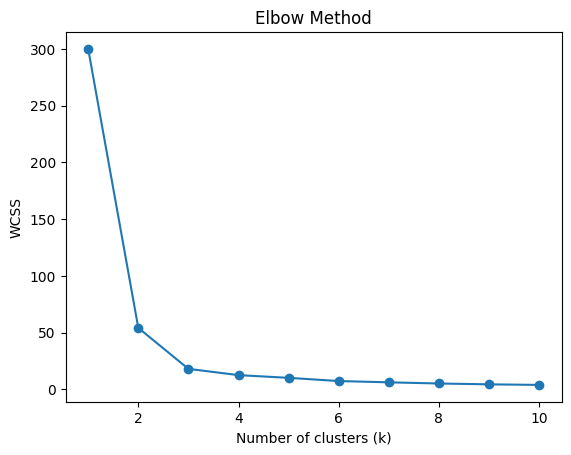

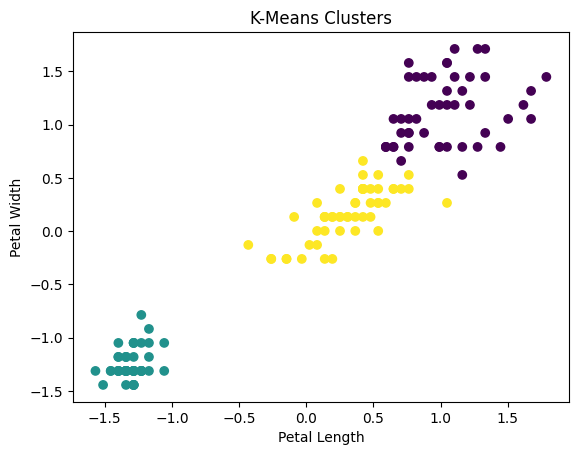

In [ ]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Load dataset (upload iris.csv in Colab)
df = pd.read_csv('/content/iris.csv')

# 3. Select only petal features
X = df[['petal_length', 'petal_width']]

# 4. Scaling (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow method to find optimal k
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# 6. Plot elbow graph
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# 7. Train final model (choose k from graph, usually 3 for iris)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 8. Visualize clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clusters')
plt.show()

In [1]:
# 1. Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# 2. Load dataset (upload heart.csv)
df = pd.read_csv('/content/heart (1).csv').dropna()

# 3. Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)   # one-hot encoding

# 4. Split features & target
X = df_encoded.drop('HeartDisease', axis=1)   # change 'target' if needed
y = df_encoded['HeartDisease']

# 5. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# 7. Train models
models = {
    "SVM": SVC(),
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier()
}

print("Without PCA:")
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(name, "Accuracy:", acc)

# 8. Apply PCA
pca = PCA(n_components=5)   # you can vary this
X_pca = pca.fit_transform(X_scaled)

# 9. Split again after PCA
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2)

# 10. Train models again
print("\nWith PCA:")
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(name, "Accuracy:", acc)

Without PCA:
SVM Accuracy: 0.8967391304347826
Logistic Accuracy: 0.8695652173913043
RandomForest Accuracy: 0.8913043478260869

With PCA:
SVM Accuracy: 0.8695652173913043
Logistic Accuracy: 0.842391304347826
RandomForest Accuracy: 0.8478260869565217
